In [1]:
# download a small GloVe model (Wikipedia + Gigaword, 50D)

# NOTE: If you get errors importing, run the following !pip... line,
# then restart your session (from Runtime menu) and comment out the pip line.
# !pip install gensim

import gensim.downloader as api
wiki = api.load('glove-wiki-gigaword-50')
twit = api.load('glove-twitter-50')

In [2]:
import matplotlib.pyplot as plt

In [3]:
dir(twit)

['__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adapt_by_suffix',
 '_load_specials',
 '_log_evaluate_word_analogies',
 '_save_specials',
 '_smart_save',
 '_upconvert_old_d2vkv',
 '_upconvert_old_vocab',
 'add_lifecycle_event',
 'add_vector',
 'add_vectors',
 'allocate_vecattrs',
 'closer_than',
 'cosine_similarities',
 'distance',
 'distances',
 'doesnt_match',
 'evaluate_word_analogies',
 'evaluate_word_pairs',
 'expandos',
 'fill_norms',
 'get_index',
 'get_mean_vector',
 'get_normed_vectors',
 'get_vecattr',
 'get_vector',
 'has_index_for',
 'index2entity',
 'index2word',
 'index_to_key'

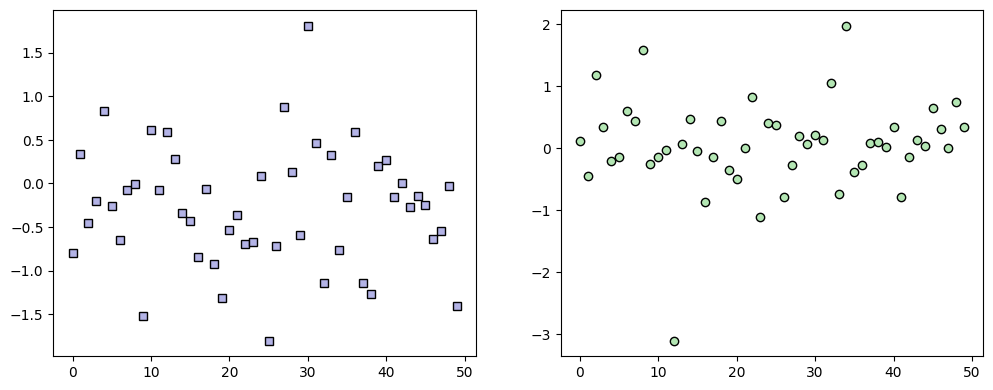

In [4]:
_, axs = plt.subplots(1,2, figsize=(12, 4.5))
axs[0].plot(wiki["flag"], "ks", markerfacecolor=[.7, .7, .9])
axs[1].plot(twit["flag"], "ko", markerfacecolor=[.7, .9, .7])


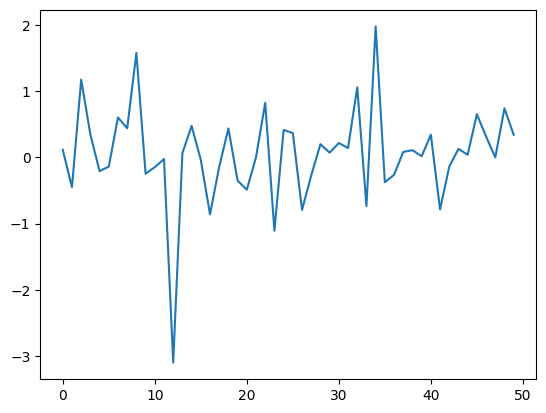

In [5]:
plt.plot(twit["flag"])

[Text(0.5, 1.0, 'Wiki (Cosine Similarity: 0.5915805697441101)'),
 Text(0.5, 0, 'Embedding for Wiki'),
 Text(0, 0.5, 'Embedding for Table')]

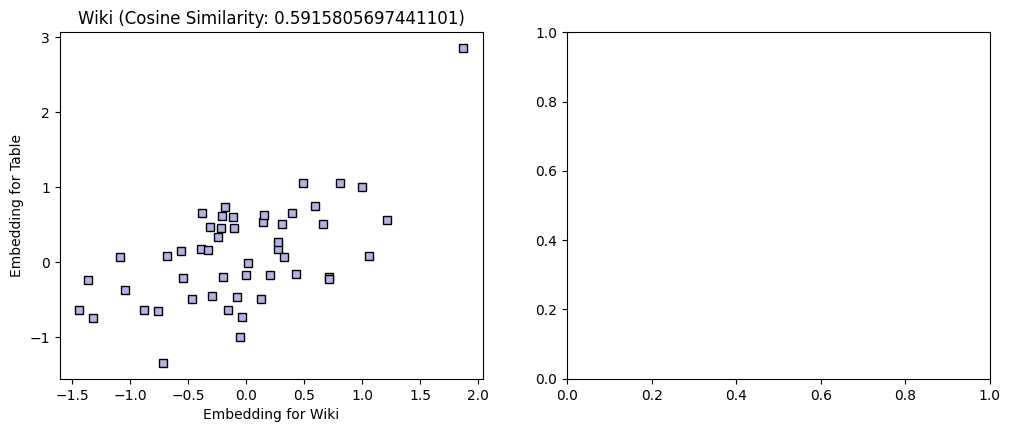

In [6]:
w_chair_embed = wiki["chair"]
w_table_embed = wiki["table"]

wiki_sim = wiki.similarity('table', 'chair')
twit_sim = twit.similarity('table', 'chair')

_, axs = plt.subplots(1,2, figsize=(12, 4.5))
axs[0].plot(w_chair_embed, w_table_embed, "ks", markerfacecolor=[.7, .7, .9])
axs[0].set(title=f"Wiki (Cosine Similarity: {wiki_sim})",
           xlabel="Embedding for Wiki",
           ylabel="Embedding for Table")
# axs[1].plot(twit["flag"], "ko", markerfacecolor=[.7, .9, .7])

# print(wiki_sim)
# print(twit_sim)

In [7]:
simword = "battery"

print(f"{simword} similarity in twitter...")

twit_sim = twit.most_similar(simword)

for word, sim in twit_sim:
    print(f"{word} with similarity {sim}")


print(f"\n{simword} similarity in Wikipedia...")

wiki_sim = wiki.most_similar(simword)

for word, sim in wiki_sim:
    print(f"{word} with similarity {sim}")

battery similarity in twitter...
charger with similarity 0.8720738887786865
cell with similarity 0.8216446042060852
batteries with similarity 0.8167192935943604
laptop with similarity 0.8139174580574036
batt with similarity 0.8042665719985962
charging with similarity 0.7880637049674988
replacement with similarity 0.7854103446006775
adapter with similarity 0.7587377429008484
phone with similarity 0.7571932077407837
charge with similarity 0.749850869178772

battery similarity in Wikipedia...
batteries with similarity 0.8322107195854187
rechargeable with similarity 0.7258116602897644
lithium-ion with similarity 0.7082582116127014
weapon with similarity 0.6928435564041138
machine with similarity 0.6787962913513184
lead-acid with similarity 0.6765270233154297
device with similarity 0.6705914735794067
anti-aircraft with similarity 0.6586135029792786
gun with similarity 0.6580089330673218
electric with similarity 0.6576830744743347


(np.float32(0.5533112), np.float32(0.40359738), np.float32(0.6052315), np.float32(0.10618009), np.float32(0.35711366), np.float32(0.82433194), np.float32(0.12410711), np.float32(0.6127797))
(np.float32(0.6592193), np.float32(0.54223436), np.float32(0.65168035), np.float32(0.3082923), np.float32(0.4618986), np.float32(0.7950631), np.float32(0.60703444), np.float32(0.67286325))


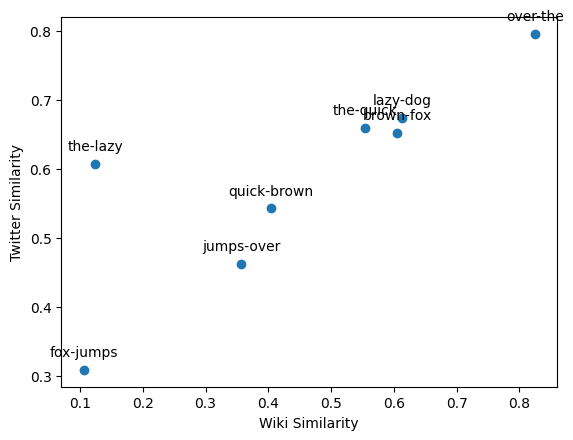

In [21]:
sent = "the quick brown fox jumps over the lazy dog"

sent_list = [word for word in sent.split(' ')]

wiki_sim_comparison = {}
twit_sim_comparison = {}

for i in range(len(sent_list) - 1):
    word = sent_list[i]
    next_word = sent_list[i + 1]

    wiki_sim_comparison[word + "-" + next_word] = wiki.similarity(word, next_word)
    twit_sim_comparison[word + "-" + next_word] = twit.similarity(word, next_word)

word_combos, wiki_sim = zip(*wiki_sim_comparison.items())
_, twit_sim = zip(*twit_sim_comparison.items())

print(wiki_sim)
print(twit_sim)

plt.scatter(wiki_sim, twit_sim)
plt.xlabel("Wiki Similarity")
plt.ylabel("Twitter Similarity")

# Loop through each point and add the annotation
for i, label in enumerate(word_combos):
    plt.annotate(
        label,              # The text label
        (wiki_sim[i], twit_sim[i]),       # The point to annotate (xy)
        textcoords="offset points", # How to position the text
        xytext=(0, 10),     # Offset (x, y) from the point
        ha='center'         # Horizontal alignment of the text
    )



# word_combos, wiki_sim = zip(*wiki_sim_comparison)
# print(word_combos)
